<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/15_document_image_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 15 — Document Image Augmentation with AugLy

## What This Notebook Covers
Document images (scanned forms, receipts, contracts, ID cards, screenshots)
present unique augmentation challenges compared to natural images.
The key characteristics:
- Text and layout carry semantic meaning — aggressive geometric distortion
  can destroy readability
- Real-world documents suffer from scan artifacts, low quality cameras,
  perspective distortion, stamps, handwriting overlays
- Models must be robust to quality degradation while preserving
  the ability to read text and recognize layout structure

**Libraries used:**
- `AugLy` (Facebook Research) — realistic social-media and document distortions
- `albumentations` — geometric and quality degradation transforms
- `PIL` / `cv2` — custom document-specific augmentations

**Techniques covered:**
- Quality degradation: JPEG compression, blur, noise, low resolution
- Scan artifacts: brightness variation, shadow overlay, paper texture
- Geometric: perspective warp, slight rotation, border addition
- Overlay: stamps, watermarks, handwriting simulation
- Pixelization and encoding quality
- Full pipeline composition
- Document classifier A/B test

**Dataset:** RVL-CDIP document image classification (subset) or synthetic docs


In [1]:
!pip install augly albumentations --quiet

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import albumentations as A
import cv2
import random
import os
import io

try:
    import augly.image as imaugs
    AUGLY_OK = True
    print('AugLy loaded successfully')
except ImportError:
    AUGLY_OK = False
    print('AugLy not available — run: pip install augly')

np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 28.8 MB/s eta 0:00:00
AugLy loaded successfully
Device: cuda


## 1. Generate Synthetic Document Images

Rather than downloading a large dataset, we generate realistic-looking
synthetic documents with different layouts:
- Letter / form (text-heavy, structured)
- Invoice / table (tabular layout)
- ID card (short text, photo placeholder)
- Receipt (narrow, list format)

This gives us a clean baseline to clearly demonstrate each augmentation.


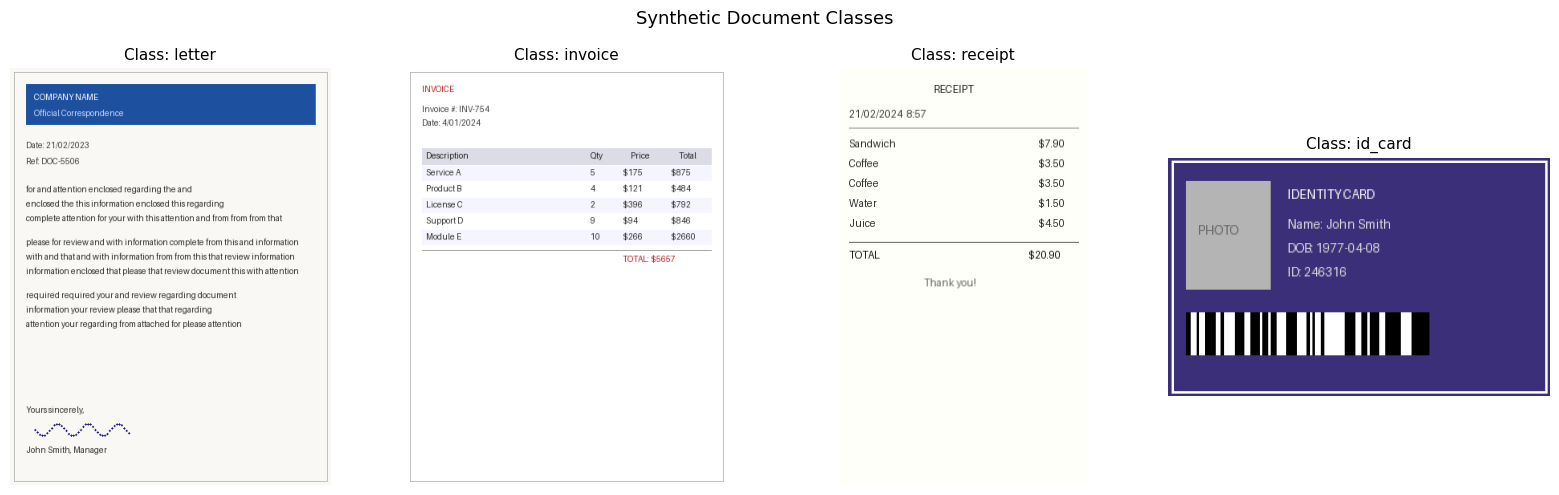

4 document class generators ready.


In [2]:
def make_letter_doc(width=400, height=520, seed=0):
    """Generate a synthetic letter / form document."""
    rng = random.Random(seed)
    img  = Image.new('RGB', (width, height), color=(250, 248, 245))
    draw = ImageDraw.Draw(img)

    # Header
    draw.rectangle([20, 20, width-20, 70], fill=(30, 80, 160))
    draw.text((30, 30), 'COMPANY NAME', fill='white')
    draw.text((30, 50), 'Official Correspondence', fill=(200, 220, 255))

    # Date and reference
    draw.text((20, 90),  f'Date: {rng.randint(1,28)}/0{rng.randint(1,9)}/202{rng.randint(3,5)}',
               fill=(60, 60, 60))
    draw.text((20, 110), f'Ref: DOC-{rng.randint(1000,9999)}', fill=(60, 60, 60))

    # Body text lines
    y = 145
    sample_words = ['the', 'and', 'for', 'this', 'that', 'with', 'from', 'your',
                    'please', 'enclosed', 'regarding', 'information', 'document',
                    'attention', 'required', 'complete', 'review', 'attached']
    for para in range(3):
        for line in range(rng.randint(3, 5)):
            n_words = rng.randint(6, 12)
            line_text = ' '.join(rng.choices(sample_words, k=n_words))
            draw.text((20, y), line_text, fill=(40, 40, 40))
            y += 18
        y += 12

    # Signature block
    draw.text((20, height-100), 'Yours sincerely,', fill=(40, 40, 40))
    # Squiggly signature simulation
    sx, sy = 30, height-70
    for i in range(40):
        x1 = sx + i*3
        y1 = sy + int(8 * np.sin(i * 0.5))
        draw.ellipse([x1, y1, x1+2, y1+2], fill=(20, 20, 120))
    draw.text((20, height-50), 'John Smith, Manager', fill=(40, 40, 40))

    # Page border
    draw.rectangle([5, 5, width-5, height-5], outline=(180, 180, 180), width=1)
    return img


def make_invoice_doc(width=400, height=520, seed=0):
    """Generate a synthetic invoice document."""
    rng = random.Random(seed)
    img  = Image.new('RGB', (width, height), color=(255, 255, 255))
    draw = ImageDraw.Draw(img)

    draw.text((20, 20), 'INVOICE', fill=(180, 30, 30))
    draw.text((20, 45), f'Invoice #: INV-{rng.randint(100,999)}', fill=(60, 60, 60))
    draw.text((20, 62), f'Date: {rng.randint(1,28)}/0{rng.randint(1,9)}/2024',
               fill=(60, 60, 60))

    # Table header
    y = 100
    draw.rectangle([20, y, width-20, y+20], fill=(220, 220, 230))
    draw.text((25, y+3),  'Description', fill=(30, 30, 30))
    draw.text((230, y+3), 'Qty', fill=(30, 30, 30))
    draw.text((280, y+3), 'Price', fill=(30, 30, 30))
    draw.text((340, y+3), 'Total', fill=(30, 30, 30))
    y += 22

    items = ['Service A', 'Product B', 'License C', 'Support D', 'Module E']
    total = 0
    for i, item in enumerate(items[:rng.randint(3,5)]):
        qty   = rng.randint(1, 10)
        price = rng.randint(50, 500)
        line_total = qty * price
        total += line_total
        bg = (245, 245, 255) if i % 2 == 0 else (255, 255, 255)
        draw.rectangle([20, y, width-20, y+18], fill=bg)
        draw.text((25, y+2),  item, fill=(40, 40, 40))
        draw.text((230, y+2), str(qty), fill=(40, 40, 40))
        draw.text((270, y+2), f'${price}', fill=(40, 40, 40))
        draw.text((330, y+2), f'${line_total}', fill=(40, 40, 40))
        y += 20

    draw.line([20, y+5, width-20, y+5], fill=(150, 150, 150), width=1)
    draw.text((270, y+10), f'TOTAL: ${total}', fill=(180, 30, 30))
    draw.rectangle([5, 5, width-5, height-5], outline=(180, 180, 180), width=1)
    return img


def make_receipt_doc(width=250, height=420, seed=0):
    """Generate a synthetic receipt."""
    rng = random.Random(seed)
    img  = Image.new('RGB', (width, height), color=(255, 255, 250))
    draw = ImageDraw.Draw(img)

    draw.text((width//2 - 30, 15), 'RECEIPT', fill=(30, 30, 30))
    draw.text((10, 40), f'{rng.randint(1,28)}/0{rng.randint(1,9)}/2024  {rng.randint(8,22)}:'
               f'{rng.randint(10,59):02d}', fill=(60, 60, 60))
    draw.line([10, 60, width-10, 60], fill=(150, 150, 150), width=1)

    items = [('Coffee', 3.50), ('Sandwich', 7.90), ('Cookie', 2.00),
             ('Juice', 4.50), ('Water', 1.50), ('Muffin', 3.00)]
    y = 70
    total = 0.0
    for item, price in rng.choices(items, k=rng.randint(3, 6)):
        draw.text((10, y),       item,       fill=(40, 40, 40))
        draw.text((width-50, y), f'${price:.2f}', fill=(40, 40, 40))
        total += price
        y += 20

    draw.line([10, y+5, width-10, y+5], fill=(100, 100, 100), width=1)
    draw.text((10, y+12), 'TOTAL', fill=(20, 20, 20))
    draw.text((width-60, y+12), f'${total:.2f}', fill=(20, 20, 20))
    draw.text((width//2-40, y+40), 'Thank you!', fill=(100, 100, 100))
    return img


def make_id_card(width=320, height=200, seed=0):
    """Generate a synthetic ID card."""
    rng = random.Random(seed)
    img  = Image.new('RGB', (width, height),
                     color=(rng.randint(20,60), rng.randint(40,100), rng.randint(120,180)))
    draw = ImageDraw.Draw(img)

    # Photo placeholder
    draw.rectangle([15, 20, 85, 110], fill=(180, 180, 180))
    draw.text((25, 55), 'PHOTO', fill=(100, 100, 100))

    # Text fields
    draw.text((100, 25), 'IDENTITY CARD', fill='white')
    draw.text((100, 50), f'Name: John Smith',  fill=(220, 220, 220))
    draw.text((100, 70), f'DOB: {rng.randint(1960,2000)}-0{rng.randint(1,9)}-{rng.randint(1,28):02d}',
               fill=(220, 220, 220))
    draw.text((100, 90), f'ID: {rng.randint(100000, 999999)}', fill=(220, 220, 220))

    # Barcode simulation
    bx = 15
    for i in range(60):
        w = rng.randint(1, 4)
        color = (0, 0, 0) if rng.random() > 0.4 else (255, 255, 255)
        draw.rectangle([bx, 130, bx+w, 165], fill=color)
        bx += w + 1

    draw.rectangle([3, 3, width-3, height-3], outline='white', width=2)
    return img


DOC_CLASSES = {
    'letter': make_letter_doc,
    'invoice': make_invoice_doc,
    'receipt': make_receipt_doc,
    'id_card': make_id_card,
}
CLASS_NAMES = list(DOC_CLASSES.keys())
CLASS2IDX   = {c: i for i, c in enumerate(CLASS_NAMES)}

# Preview one of each type
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, (name, fn) in zip(axes, DOC_CLASSES.items()):
    doc = fn(seed=42)
    ax.imshow(doc)
    ax.set_title(f'Class: {name}', fontsize=11)
    ax.axis('off')
plt.suptitle('Synthetic Document Classes', fontsize=13)
plt.tight_layout()
plt.show()
print('4 document class generators ready.')

## 2. Visualisation Helper


In [3]:
def show_doc_aug(original_pil, aug_fn, n=4, title=''):
    """
    Apply aug_fn to the document n times and display results.
    original_pil: PIL Image
    aug_fn: callable(PIL Image) -> PIL Image
    """
    fig, axes = plt.subplots(1, n + 1, figsize=(3 * (n+1), 4))
    axes[0].imshow(original_pil)
    axes[0].set_title('Original', fontsize=9)
    axes[0].axis('off')

    for i in range(n):
        try:
            augmented = aug_fn(original_pil.copy())
            if isinstance(augmented, np.ndarray):
                augmented = Image.fromarray(augmented.astype(np.uint8))
        except Exception as e:
            augmented = original_pil
            print(f'Aug failed: {e}')
        axes[i+1].imshow(augmented)
        axes[i+1].set_title(f'Aug {i+1}', fontsize=9)
        axes[i+1].axis('off')

    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

SAMPLE_DOC = make_letter_doc(seed=42)
print('Sample document ready.')

Sample document ready.


## 3. Quality Degradation Augmentations

These simulate the document being photographed with a low-quality
camera, scanned at low DPI, or heavily compressed.


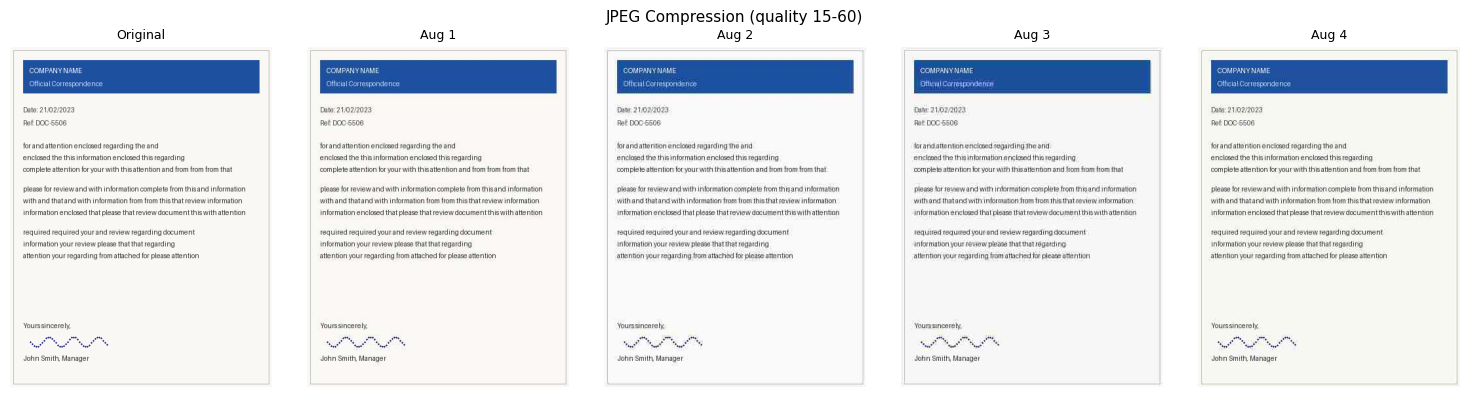

In [4]:
# JPEG compression artifacts
def jpeg_compress(pil_img, quality_range=(15, 60)):
    """
    Simulate JPEG compression artifacts by encoding and decoding.
    Lower quality -> more blocking artifacts, especially on text.
    """
    quality = random.randint(*quality_range)
    buf = io.BytesIO()
    pil_img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return Image.open(buf).copy()

show_doc_aug(SAMPLE_DOC, jpeg_compress,
             title='JPEG Compression (quality 15-60)')

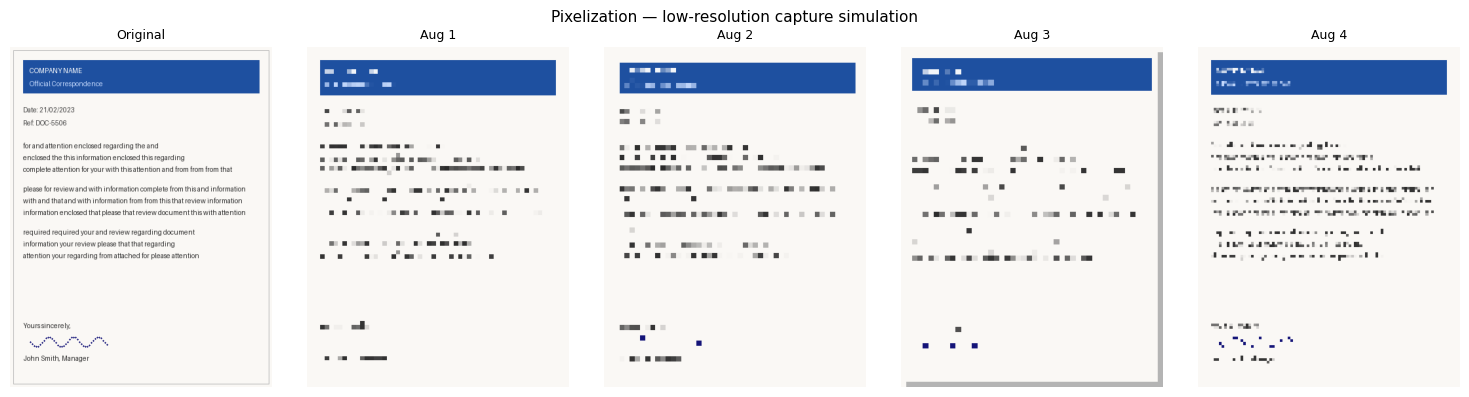

In [5]:
# Pixelization — simulate low-resolution capture then upscale
def pixelate(pil_img, factor_range=(0.1, 0.3)):
    """
    Downscale to a fraction of original size then upscale back.
    Creates blocky pixel artifacts like a low-resolution camera.
    """
    factor = random.uniform(*factor_range)
    w, h   = pil_img.size
    small  = pil_img.resize((int(w*factor), int(h*factor)), Image.NEAREST)
    return small.resize((w, h), Image.NEAREST)

show_doc_aug(SAMPLE_DOC, pixelate,
             title='Pixelization — low-resolution capture simulation')

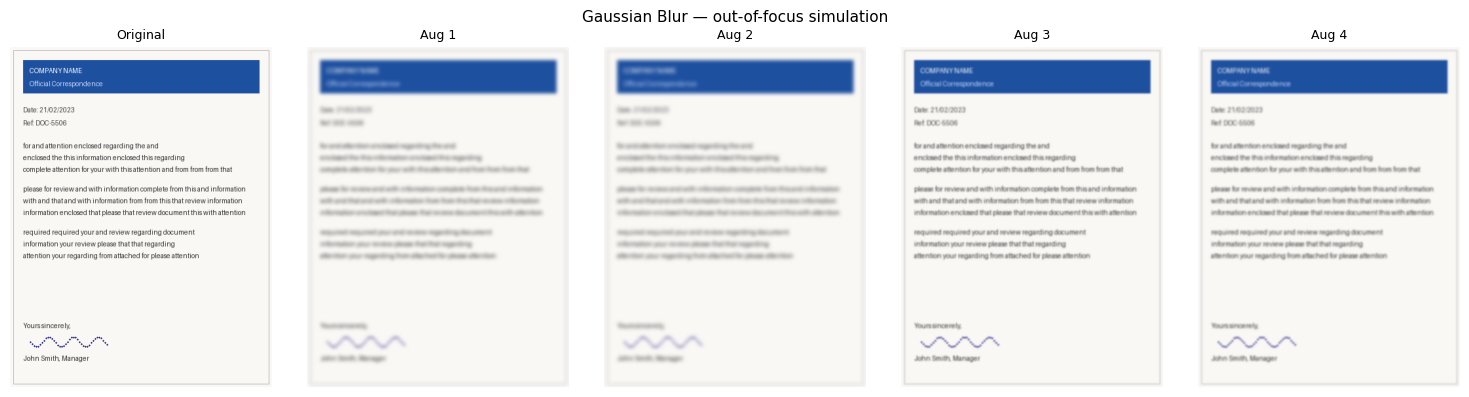

In [6]:
# Gaussian blur — simulates out-of-focus camera or motion blur
def gaussian_blur_doc(pil_img, radius_range=(1, 4)):
    radius = random.uniform(*radius_range)
    return pil_img.filter(ImageFilter.GaussianBlur(radius=radius))

show_doc_aug(SAMPLE_DOC, gaussian_blur_doc,
             title='Gaussian Blur — out-of-focus simulation')

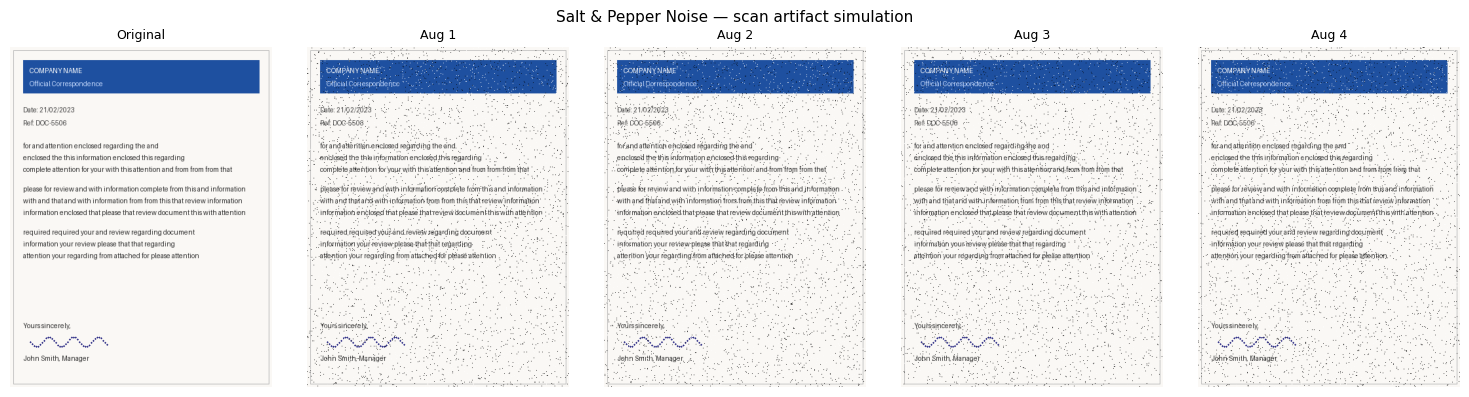

In [7]:
# Salt and pepper noise — simulates scan artifacts, dust on scanner
def salt_pepper_noise(pil_img, amount=0.02):
    arr   = np.array(pil_img).astype(np.float32)
    mask  = np.random.random(arr.shape[:2])
    arr[mask < amount/2]       = 0    # pepper
    arr[mask > 1 - amount/2]   = 255  # salt
    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

show_doc_aug(SAMPLE_DOC, lambda img: salt_pepper_noise(img, amount=0.03),
             title='Salt & Pepper Noise — scan artifact simulation')

## 4. Scan Artifact Augmentations

These simulate physical artifacts from flatbed scanners:
brightness non-uniformity, shadow from page curl, paper texture.


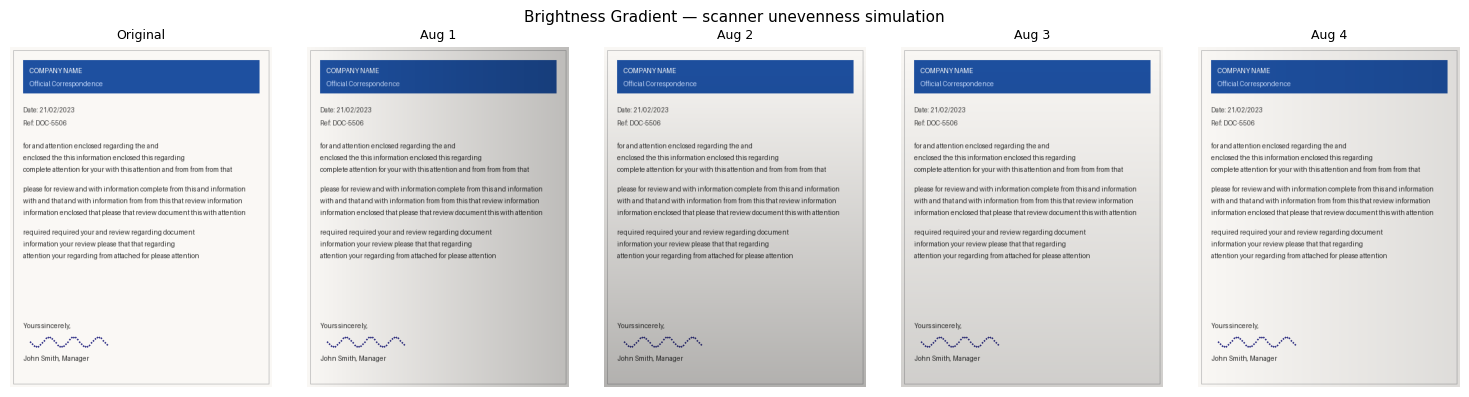

In [8]:
def brightness_gradient(pil_img, max_darkness=0.4):
    """
    Apply a gradient brightness variation across the document.
    Simulates uneven illumination when photographing a document
    or scanner lamp unevenness.
    """
    arr = np.array(pil_img).astype(np.float32)
    w   = arr.shape[1]

    # Random gradient direction
    if random.random() < 0.5:
        # Left-to-right gradient
        gradient = np.linspace(1.0, 1.0 - max_darkness * random.random(), w)
        arr *= gradient[None, :, None]
    else:
        # Top-to-bottom gradient
        h = arr.shape[0]
        gradient = np.linspace(1.0, 1.0 - max_darkness * random.random(), h)
        arr *= gradient[:, None, None]

    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

show_doc_aug(SAMPLE_DOC, brightness_gradient,
             title='Brightness Gradient — scanner unevenness simulation')

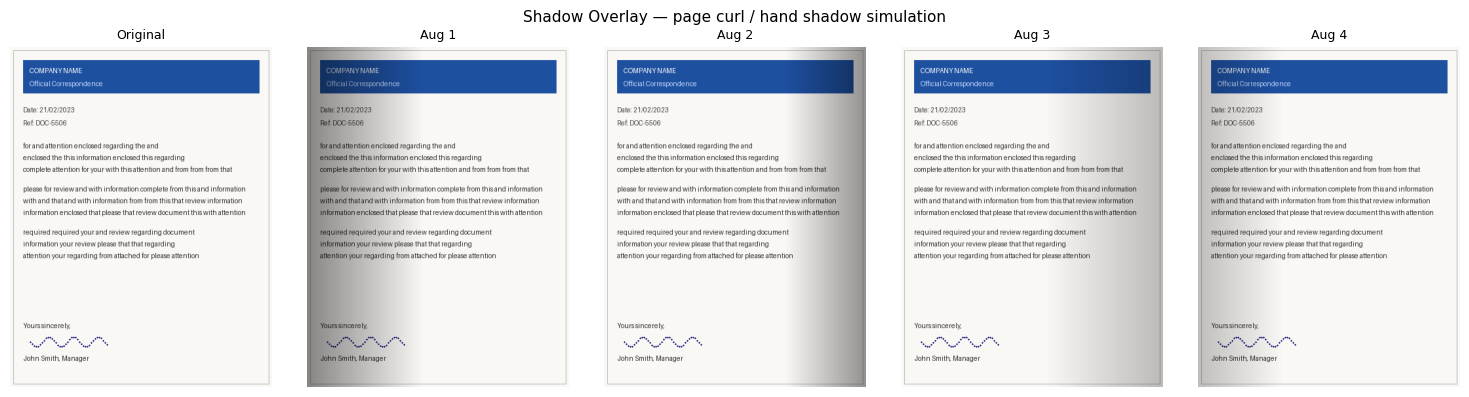

In [9]:
def shadow_overlay(pil_img, max_opacity=0.5):
    """
    Add a dark shadow from one side of the document.
    Simulates a page shadow when scanning a book or
    shadow from a hand holding a phone camera.
    """
    arr      = np.array(pil_img).astype(np.float32)
    h, w     = arr.shape[:2]
    opacity  = random.uniform(0.2, max_opacity)
    shadow_w = random.randint(w // 5, w // 2)

    # Gradient shadow on left or right
    side = random.choice(['left', 'right'])
    shadow = np.linspace(opacity, 0, shadow_w)

    if side == 'left':
        arr[:, :shadow_w] *= (1 - shadow[None, :, None])
    else:
        arr[:, -shadow_w:] *= (1 - shadow[None, ::-1, None])

    return Image.fromarray(arr.clip(0, 255).astype(np.uint8))

show_doc_aug(SAMPLE_DOC, shadow_overlay,
             title='Shadow Overlay — page curl / hand shadow simulation')

## 5. Geometric Augmentations

Documents are often not perfectly aligned. Slight perspective
distortion from phone cameras and minor rotation from scanners
are very common in real-world document datasets.


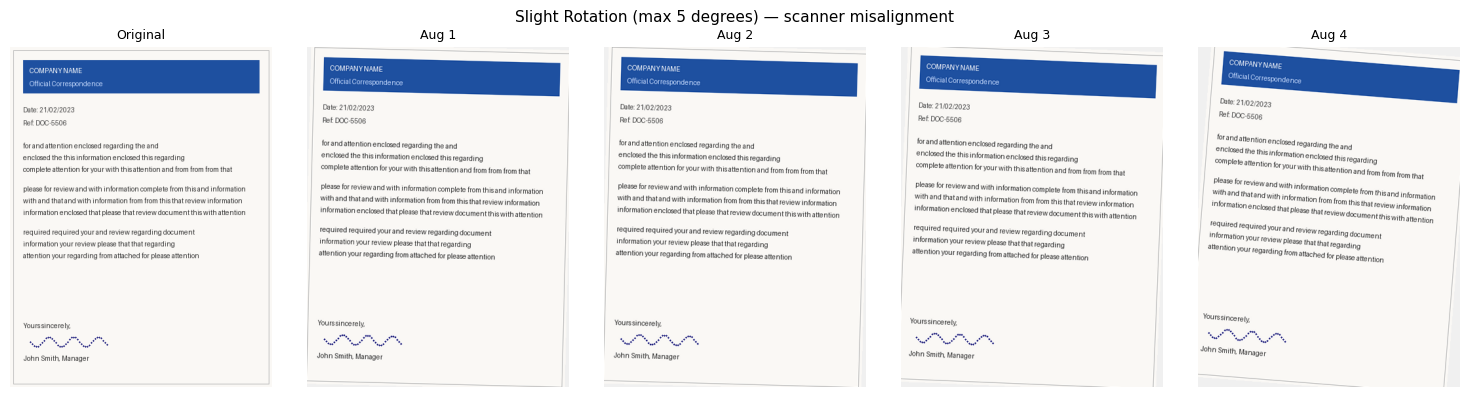

In [10]:
def slight_rotation(pil_img, max_angle=5):
    """
    Rotate the document slightly as if it was placed at an angle
    on the scanner glass. Keep max_angle small (2-5 degrees) —
    larger rotations are handled by preprocessing in real pipelines.
    """
    angle = random.uniform(-max_angle, max_angle)
    return pil_img.rotate(angle, fillcolor=(240, 240, 240),
                           resample=Image.BICUBIC)

show_doc_aug(SAMPLE_DOC, slight_rotation,
             title='Slight Rotation (max 5 degrees) — scanner misalignment')

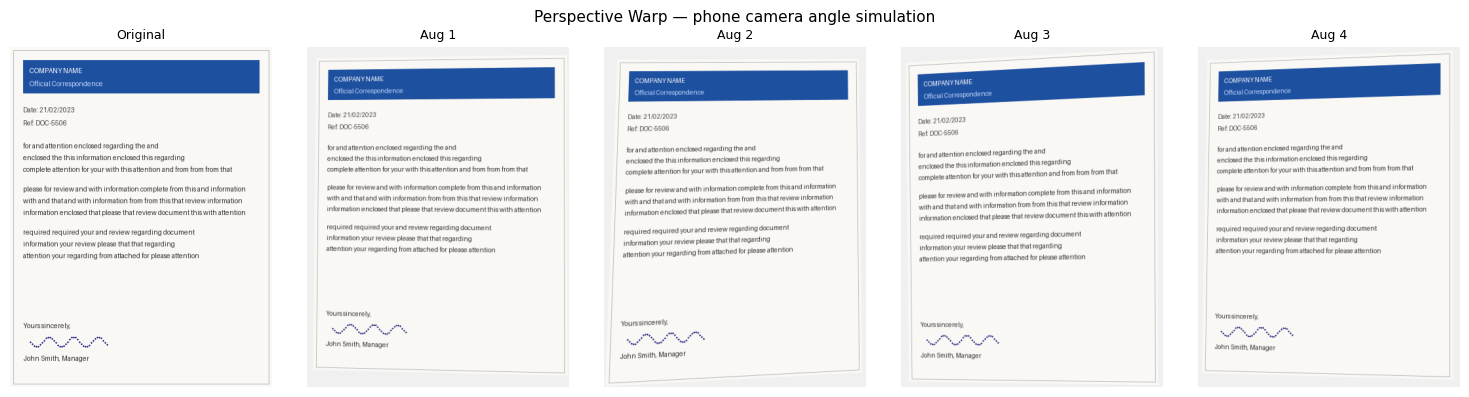

In [11]:
def perspective_warp(pil_img, distortion=0.05):
    """
    Apply a mild perspective warp simulating a phone camera
    not held perfectly perpendicular to the document.
    """
    arr = np.array(pil_img)
    h, w = arr.shape[:2]

    # Slightly shift the four corners
    dx = int(w * distortion)
    dy = int(h * distortion)

    src = np.float32([[0,0],[w,0],[w,h],[0,h]])
    dst = np.float32([
        [random.randint(0, dx),    random.randint(0, dy)],
        [w - random.randint(0,dx), random.randint(0, dy)],
        [w - random.randint(0,dx), h - random.randint(0,dy)],
        [random.randint(0, dx),    h - random.randint(0,dy)],
    ])

    M      = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(arr, M, (w, h),
                                  borderValue=(240, 240, 240))
    return Image.fromarray(warped)

show_doc_aug(SAMPLE_DOC, perspective_warp,
             title='Perspective Warp — phone camera angle simulation')

## 6. Overlay Augmentations — Stamps and Watermarks

Real documents often have stamps, watermarks, or handwritten notes.
These overlays partially occlude the text and must be handled robustly.


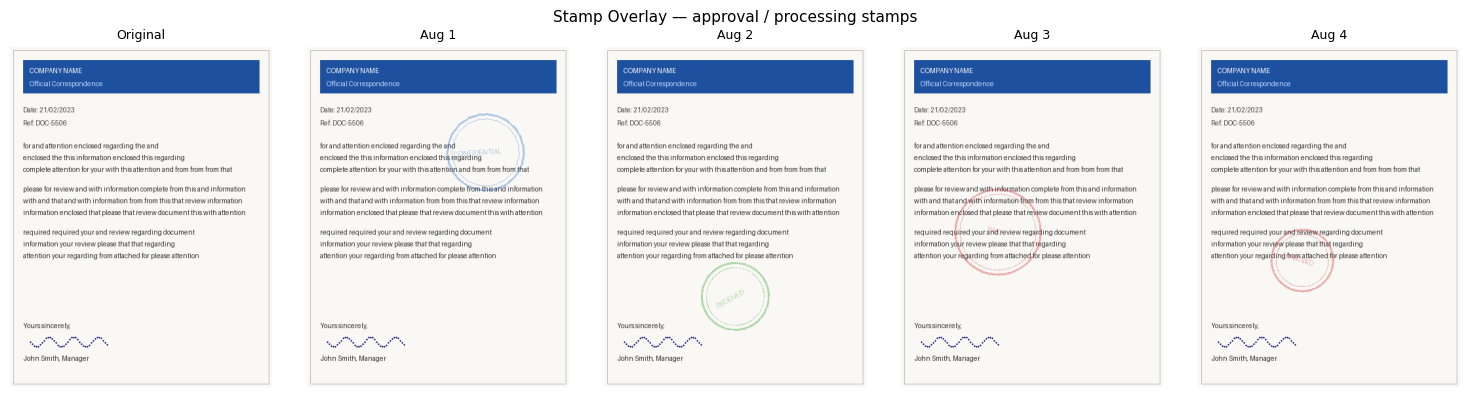

In [12]:
def add_stamp(pil_img, text='APPROVED', opacity=0.35):
    """
    Add a semi-transparent circular stamp overlay.
    The stamp is placed at a random position and angle.
    """
    stamp = Image.new('RGBA', pil_img.size, (0, 0, 0, 0))
    draw  = ImageDraw.Draw(stamp)

    w, h  = pil_img.size
    cx    = random.randint(w//4, 3*w//4)
    cy    = random.randint(h//4, 3*h//4)
    r     = random.randint(40, 70)
    alpha = int(opacity * 255)

    colors = [(200, 30, 30), (30, 100, 200), (30, 150, 30), (150, 100, 0)]
    color  = random.choice(colors)

    # Outer circle
    draw.ellipse([cx-r, cy-r, cx+r, cy+r],
                 outline=(*color, alpha), width=3)
    # Inner circle
    draw.ellipse([cx-r+8, cy-r+8, cx+r-8, cy+r-8],
                 outline=(*color, alpha), width=1)
    # Text
    draw.text((cx - len(text)*4, cy - 6), text, fill=(*color, alpha))

    # Rotate stamp
    angle = random.randint(-30, 30)
    stamp = stamp.rotate(angle)

    result = pil_img.convert('RGBA')
    result = Image.alpha_composite(result, stamp)
    return result.convert('RGB')


stamp_texts = ['APPROVED', 'RECEIVED', 'CONFIDENTIAL', 'DRAFT', 'PAID']
show_doc_aug(
    SAMPLE_DOC,
    lambda img: add_stamp(img, text=random.choice(stamp_texts)),
    title='Stamp Overlay — approval / processing stamps'
)

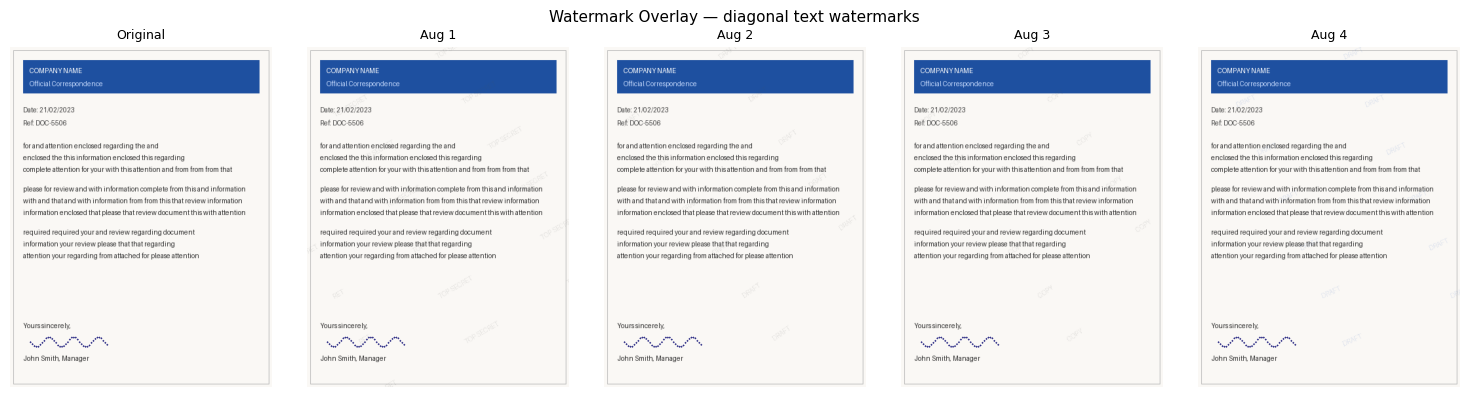

In [13]:
def add_watermark(pil_img, text='CONFIDENTIAL', opacity=0.12):
    """
    Add a diagonal text watermark across the entire document.
    Very common on official and sensitive documents.
    """
    watermark = Image.new('RGBA', pil_img.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(watermark)
    alpha = int(opacity * 255)
    color = random.choice([
        (180, 30, 30, alpha),
        (30, 80, 180, alpha),
        (80, 80, 80, alpha)
    ])

    # Tile the watermark text diagonally
    w, h = pil_img.size
    for y in range(-h, 2*h, 80):
        for x in range(-w, 2*w, 180):
            draw.text((x, y), text, fill=color)

    # Rotate 30 degrees
    watermark = watermark.rotate(random.randint(20, 40))
    result    = pil_img.convert('RGBA')
    result    = Image.alpha_composite(result, watermark)
    return result.convert('RGB')

wm_texts = ['CONFIDENTIAL', 'DRAFT', 'SAMPLE', 'COPY', 'TOP SECRET']
show_doc_aug(
    SAMPLE_DOC,
    lambda img: add_watermark(img, text=random.choice(wm_texts)),
    title='Watermark Overlay — diagonal text watermarks'
)

## 7. AugLy Document Augmentations


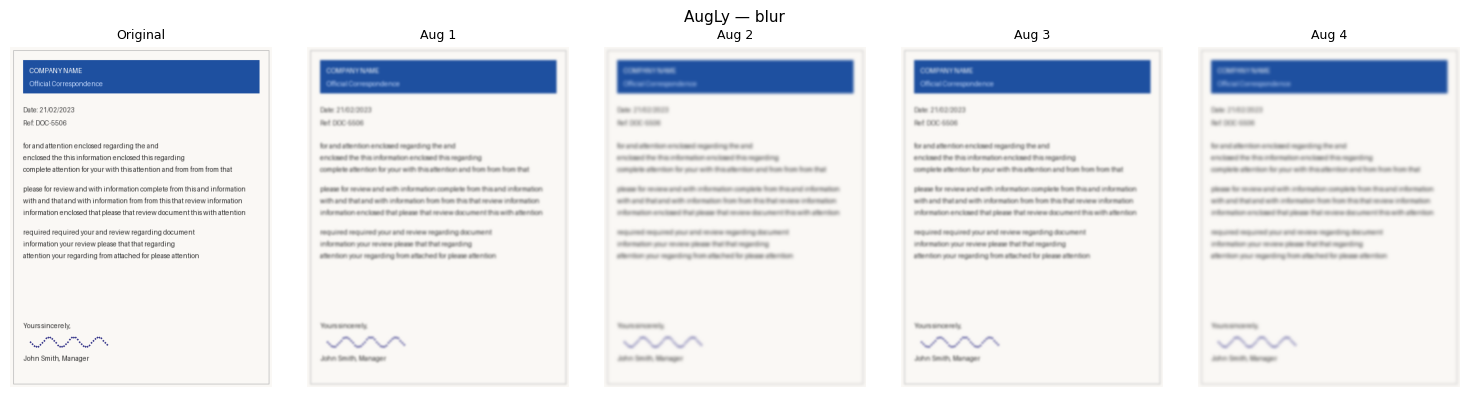

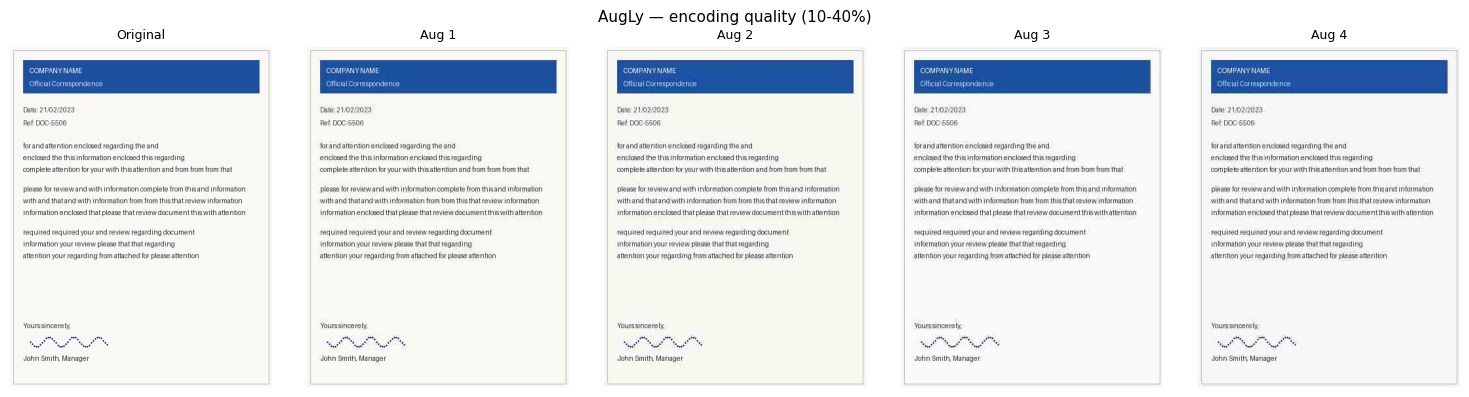

Aug failed: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
Aug failed: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
Aug failed: module 'numpy' has

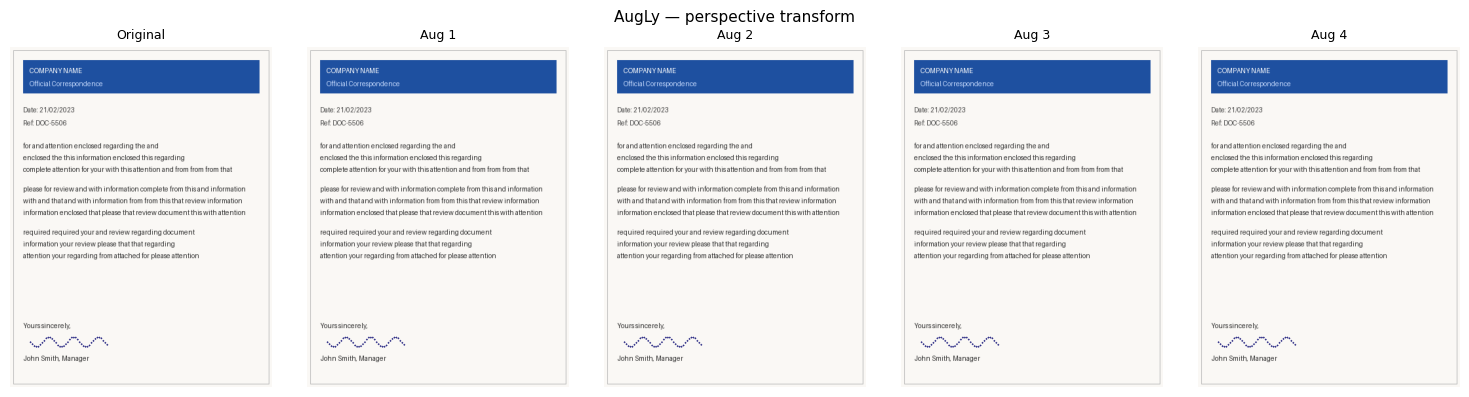

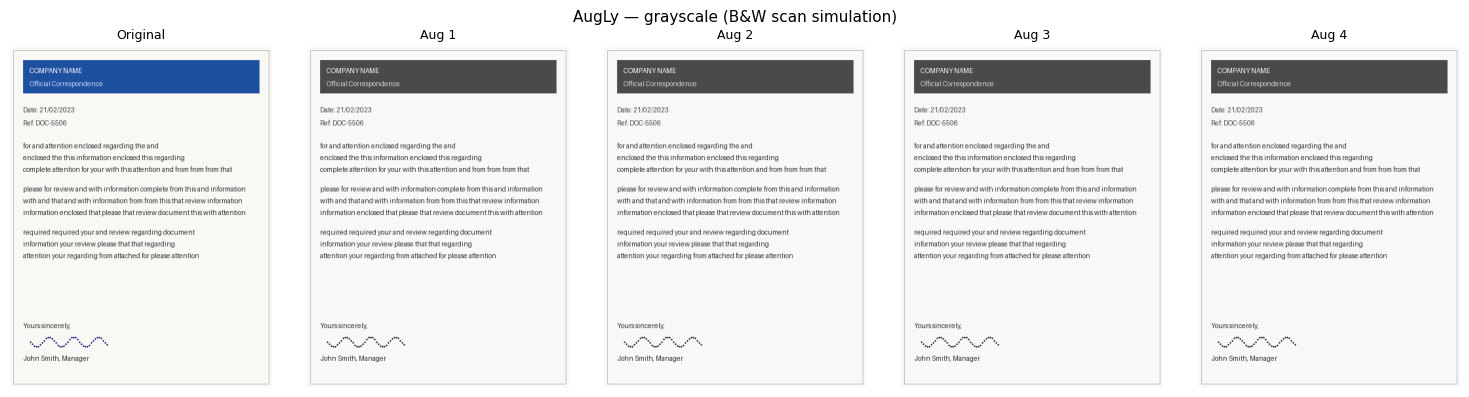

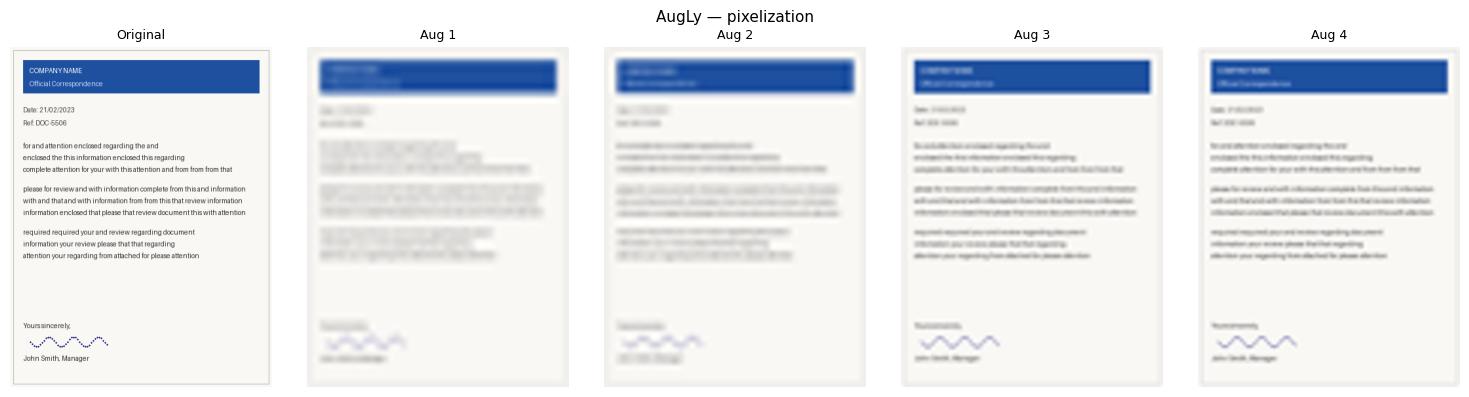

In [14]:
if AUGLY_OK:
    # Blur
    show_doc_aug(
        SAMPLE_DOC,
        lambda img: imaugs.blur(img, radius=random.uniform(1.0, 3.0)),
        title='AugLy — blur'
    )

    # Encoding quality (JPEG-like degradation)
    show_doc_aug(
        SAMPLE_DOC,
        lambda img: imaugs.encoding_quality(img, quality=random.randint(10, 40)),
        title='AugLy — encoding quality (10-40%)'
    )

    # Perspective transform
    show_doc_aug(
        SAMPLE_DOC,
        lambda img: imaugs.perspective_transform(img,
                        sigma=random.uniform(20.0, 50.0)),
        title='AugLy — perspective transform'
    )

    # Grayscale (simulate black-and-white scan)
    show_doc_aug(
        SAMPLE_DOC,
        lambda img: imaugs.grayscale(img),
        title='AugLy — grayscale (B&W scan simulation)'
    )

    # Pixelization
    show_doc_aug(
        SAMPLE_DOC,
        lambda img: imaugs.pixelization(img,
                        ratio=random.uniform(0.1, 0.25)),
        title='AugLy — pixelization'
    )
else:
    print('AugLy not available — skipping AugLy demos.')
    print('Install with: pip install augly')

## 8. Full Document Augmentation Pipeline


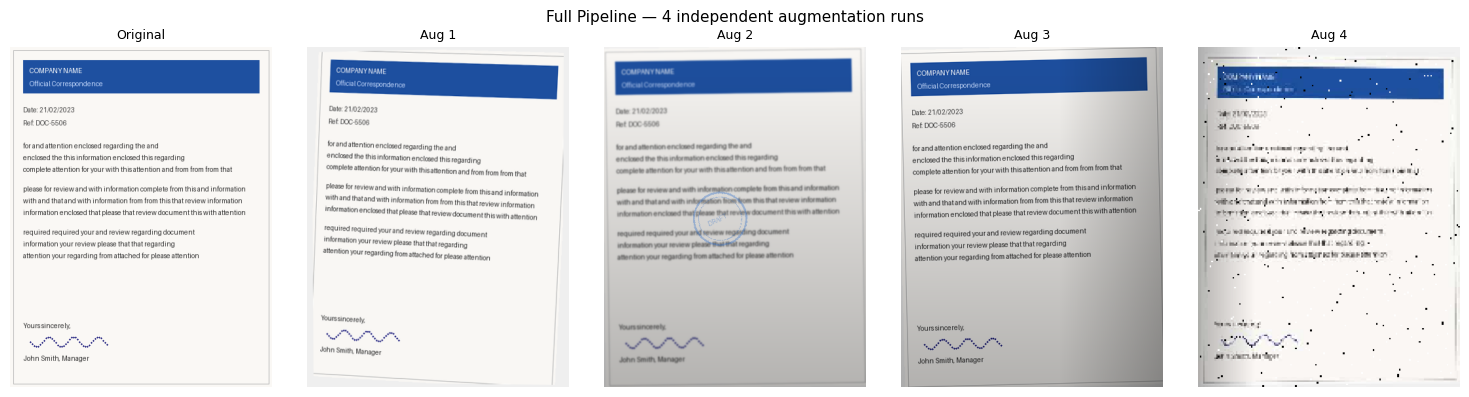

In [15]:
def document_augmentation_pipeline(pil_img, training=True):
    """
    Full document augmentation pipeline.
    Each technique applied with its own probability.
    Order: geometric -> quality -> overlay

    Input : PIL Image (any size)
    Output: PIL Image (same size)
    """
    if not training:
        return pil_img

    img = pil_img.copy()

    # --- Geometric (applied first, before quality degradation) ---
    if random.random() < 0.5:
        img = slight_rotation(img, max_angle=3)
    if random.random() < 0.4:
        img = perspective_warp(img, distortion=0.03)

    # --- Quality degradation ---
    if random.random() < 0.5:
        img = jpeg_compress(img, quality_range=(25, 75))
    if random.random() < 0.3:
        img = gaussian_blur_doc(img, radius_range=(0.5, 2.0))
    if random.random() < 0.3:
        img = brightness_gradient(img, max_darkness=0.3)
    if random.random() < 0.2:
        img = shadow_overlay(img, max_opacity=0.3)
    if random.random() < 0.15:
        img = salt_pepper_noise(img, amount=0.01)
    if random.random() < 0.1:
        img = pixelate(img, factor_range=(0.3, 0.6))

    # --- Overlays (applied last) ---
    if random.random() < 0.2:
        img = add_stamp(img, text=random.choice(['APPROVED','RECEIVED','DRAFT','PAID']))
    if random.random() < 0.15:
        img = add_watermark(img, text=random.choice(['CONFIDENTIAL','SAMPLE','COPY']))

    return img


# Preview the full pipeline
show_doc_aug(
    SAMPLE_DOC,
    lambda img: document_augmentation_pipeline(img, training=True),
    n=4,
    title='Full Pipeline — 4 independent augmentation runs'
)

## 9. Generate Dataset & PyTorch DataLoader


In [16]:
N_PER_CLASS = 150   # samples per class
IMG_SIZE    = 128   # resize to 128x128 for CNN

# Generate dataset as PIL images
all_imgs   = []
all_labels = []

DOC_SIZES = {
    'letter':  (400, 520),
    'invoice': (400, 520),
    'receipt': (250, 420),
    'id_card': (320, 200),
}

for cls_name, fn in DOC_CLASSES.items():
    w, h = DOC_SIZES[cls_name]
    for i in range(N_PER_CLASS):
        doc = fn(width=w, height=h, seed=i)
        all_imgs.append(doc)
        all_labels.append(CLASS2IDX[cls_name])

# Shuffle
idx = list(range(len(all_imgs)))
random.shuffle(idx)
all_imgs   = [all_imgs[i]   for i in idx]
all_labels = [all_labels[i] for i in idx]

# Train/test split
split      = int(0.8 * len(all_imgs))
train_imgs, test_imgs   = all_imgs[:split],   all_imgs[split:]
train_labels, test_labels = all_labels[:split], all_labels[split:]

print(f'Train: {len(train_imgs)}, Test: {len(test_imgs)}')


class DocDataset(Dataset):
    def __init__(self, imgs, labels, augment=False, img_size=IMG_SIZE):
        self.imgs    = imgs
        self.labels  = labels
        self.augment = augment

        self.to_tensor = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img   = self.imgs[idx].copy()
        label = self.labels[idx]

        if self.augment:
            img = document_augmentation_pipeline(img, training=True)

        # Ensure RGB
        if img.mode != 'RGB':
            img = img.convert('RGB')

        return self.to_tensor(img), label


BATCH_SIZE = 32

train_ds_base = DocDataset(train_imgs, train_labels, augment=False)
train_ds_aug  = DocDataset(train_imgs, train_labels, augment=True)
test_ds       = DocDataset(test_imgs,  test_labels,  augment=False)

train_loader_base = DataLoader(train_ds_base, batch_size=BATCH_SIZE,
                                shuffle=True,  num_workers=2)
train_loader_aug  = DataLoader(train_ds_aug,  batch_size=BATCH_SIZE,
                                shuffle=True,  num_workers=2)
test_loader       = DataLoader(test_ds,        batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=2)

X_b, y_b = next(iter(train_loader_aug))
print(f'Batch: {X_b.shape}  (B, C, H, W)')

Train: 480, Test: 120
Batch: torch.Size([32, 3, 128, 128])  (B, C, H, W)


## 10. Document Classifier — CNN


In [17]:
class DocCNN(nn.Module):
    """
    Lightweight CNN for document image classification.
    Input: (B, 3, 128, 128)
    Output: (B, 4) logits
    """
    def __init__(self, n_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128),nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3, padding=1), nn.BatchNorm2d(256),nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


m = DocCNN().to(device)
print(f'Output: {m(X_b.to(device)).shape}')
print(f'Params: {sum(p.numel() for p in m.parameters()):,}')

Output: torch.Size([32, 4])
Params: 422,788


## 11. A/B Test: No Augmentation vs Full Pipeline


In [18]:
def train_doc_model(train_loader, label='', epochs=25):
    torch.manual_seed(42)
    model     = DocCNN(n_classes=4).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    hist     = {'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        correct = total = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            out  = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            correct += (out.detach().argmax(1) == y_b).sum().item()
            total   += y_b.size(0)
        train_acc = correct / total

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)
        test_acc = correct / total
        best_acc = max(best_acc, test_acc)

        scheduler.step()
        hist['train_acc'].append(train_acc)
        hist['test_acc'].append(test_acc)

        if (epoch + 1) % 5 == 0:
            print(f'[{label}] Epoch {epoch+1:2d} | '
                  f'train={train_acc:.4f} | test={test_acc:.4f}')

    print(f'[{label}] Best test accuracy: {best_acc:.4f}\n')
    return hist, best_acc


print('Training baseline (no augmentation)...')
hist_base, acc_base = train_doc_model(
    train_loader_base, 'No aug', epochs=25
)

print('Training with full document augmentation pipeline...')
hist_aug, acc_aug = train_doc_model(
    train_loader_aug, 'Augmented', epochs=25
)

Training baseline (no augmentation)...
[No aug] Epoch  5 | train=1.0000 | test=1.0000
[No aug] Epoch 10 | train=1.0000 | test=1.0000
[No aug] Epoch 15 | train=1.0000 | test=1.0000
[No aug] Epoch 20 | train=1.0000 | test=1.0000
[No aug] Epoch 25 | train=1.0000 | test=1.0000
[No aug] Best test accuracy: 1.0000

Training with full document augmentation pipeline...
[Augmented] Epoch  5 | train=0.9958 | test=0.6167
[Augmented] Epoch 10 | train=1.0000 | test=1.0000
[Augmented] Epoch 15 | train=1.0000 | test=1.0000
[Augmented] Epoch 20 | train=1.0000 | test=1.0000
[Augmented] Epoch 25 | train=1.0000 | test=1.0000
[Augmented] Best test accuracy: 1.0000



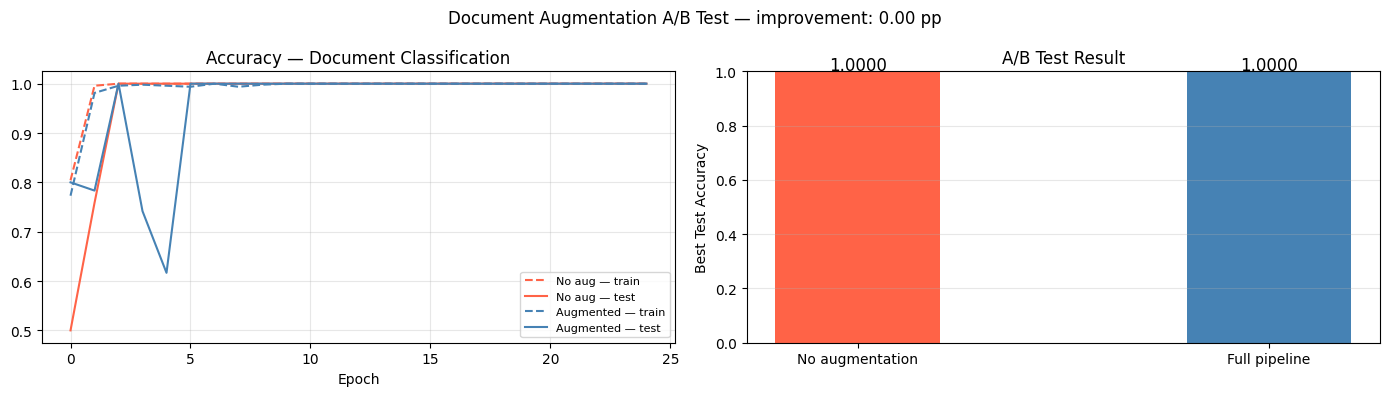

No augmentation  : 1.0000
With augmentation: 1.0000
Improvement      : 0.00 percentage points


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_base['train_acc'], '--', color='tomato',    label='No aug — train')
axes[0].plot(hist_base['test_acc'],        color='tomato',    label='No aug — test')
axes[0].plot(hist_aug['train_acc'],  '--', color='steelblue', label='Augmented — train')
axes[0].plot(hist_aug['test_acc'],         color='steelblue', label='Augmented — test')
axes[0].set_title('Accuracy — Document Classification')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

bars = axes[1].bar(
    ['No augmentation', 'Full pipeline'],
    [acc_base, acc_aug],
    color=['tomato', 'steelblue'], width=0.4
)
for bar, acc in zip(bars, [acc_base, acc_aug]):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{acc:.4f}', ha='center', fontsize=12
    )
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Best Test Accuracy')
axes[1].set_title('A/B Test Result')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Document Augmentation A/B Test — '
    f'improvement: {(acc_aug - acc_base)*100:.2f} pp',
    fontsize=12
)
plt.tight_layout()
plt.show()

print(f'No augmentation  : {acc_base:.4f}')
print(f'With augmentation: {acc_aug:.4f}')
print(f'Improvement      : {(acc_aug - acc_base)*100:.2f} percentage points')

---
## Summary

### Document Augmentation Reference

| Technique | What it simulates | Key parameter |
|---|---|---|
| JPEG compression | Low-quality scan or photo | quality (10-60) |
| Pixelization | Low-resolution camera | downscale factor |
| Gaussian blur | Out-of-focus, motion blur | radius (0.5-4) |
| Salt & pepper noise | Scanner dust, damaged paper | amount (0.01-0.05) |
| Brightness gradient | Scanner lamp unevenness | max_darkness |
| Shadow overlay | Page curl, hand shadow | opacity |
| Slight rotation | Misaligned scan placement | max_angle (2-5 deg) |
| Perspective warp | Phone camera angle | distortion (0.02-0.08) |
| Stamp overlay | Processing stamps | text, opacity |
| Watermark | Confidentiality markings | text, opacity |

### Pipeline Order Matters
```
1. Geometric (rotation, perspective) — applied to clean image
2. Quality degradation (JPEG, blur, noise) — applied after geometry
3. Overlays (stamps, watermarks) — applied last so they appear on degraded doc
```

### Key Difference from Natural Image Augmentation
Keep geometric distortions mild. Unlike natural images, documents
carry meaning in their text and layout structure. Large rotations
or extreme perspective warps can make the document unreadable —
which is worse than no augmentation at all.

**This completes Part 1K — Multi-modality augmentation.**
**Next: Notebook 16** — Custom Learning Rate Scheduler (Part 2 begins)
